In [1]:
from pathlib import Path
import subprocess

REPO_URL = "https://github.com/seoultechpse/fenicsx-colab.git"
ROOT = Path("/content")
REPO_DIR = ROOT / "fenicsx-colab"

subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

USE_COMPLEX = False  # <--- Set True ONLY if you need complex PETSc
USE_CLEAN = False    # <--- Set True to remove existing environment

opts_str = " ".join(
  [o for c, o in [(USE_COMPLEX, "--complex"), (USE_CLEAN, "--clean")] if c]
)

get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_fenicsx.py'} {opts_str}")

🔧 FEniCSx Setup Configuration
PETSc type      : real
Clean install   : False

⚠️  Google Drive not mounted — using local cache (/content)

🔧 Installing FEniCSx environment...

🔍 Verifying PETSc type...
✅ Installed: Real PETSc (float64)

✨ Loading FEniCSx Jupyter magic... %%fenicsx registered

✅ FEniCSx setup complete!

Next steps:
  1. Run %%fenicsx --info to verify installation
  2. Use %%fenicsx in cells to run FEniCSx code
  3. Use -np N for parallel execution (e.g., %%fenicsx -np 4)

📌 Note: Real PETSc is installed
   - Recommended for most FEM problems
   - For complex problems, reinstall with --complex


---

In [2]:
%%fenicsx

# Mixed Finite Element Method: Stokes Problem
# Complete implementation for Google Colab
# Based on: https://jsdokken.com/FEniCS-workshop/src/deep_dive/mixed_problems.html

# ============================================================================
# CONFIGURATION
# ============================================================================

# Mesh resolution - adjust for accuracy vs. speed trade-off
MESH_RESOLUTION = 60  # Options: 20 (fast), 40 (good), 60 (better), 80 (best)

# Boundary condition options
INLET_CHOICE = 'Quartic'  # Options: 'Parabolic', 'Quartic', 'Uniform'

# Solver options
USE_PRESSURE_PINNING = True   # Pin pressure at a point (recommended)
USE_MEAN_PRESSURE_REMOVAL = True  # Remove mean pressure (recommended)
USE_PETSC_SOLVER = False  # Use PETSc direct solver (alternative to SciPy)
                          # NOTE: PETSc direct solver gives same results as SciPy
                          # Set to True only if you want to use MUMPS factorization

# Visualization options
SAVE_PARAVIEW_FILES = True
CREATE_MATPLOTLIB_PLOTS = True

print("="*70)
print("CONFIGURATION")
print("="*70)
print(f"Mesh resolution: {MESH_RESOLUTION}x{MESH_RESOLUTION}")
print(f"Inlet type: {INLET_CHOICE}")
print(f"Pressure pinning: {USE_PRESSURE_PINNING}")
print(f"Mean pressure removal: {USE_MEAN_PRESSURE_REMOVAL}")
print(f"PETSc solver: {USE_PETSC_SOLVER}")
if USE_PETSC_SOLVER:
    print("  (PETSc will use direct LU factorization)")
if INLET_CHOICE == 'Parabolic':
    print("\nParabolic inlet profile:")
    print("  u_x(y) = 6 * y * (1-y)  [max=1.5 at center]")
    print("  u_y = 0")
    print("  Benefits: Smooth at corners, better mass conservation")
elif INLET_CHOICE == 'Quartic':
    print("\nQuartic inlet profile:")
    print("  u_x(y) = 30 * y**2 * (1-y)**2  [max=1.5 at center]")
    print("  u_y = 0")
    print("  Benefits: Smooth at corners, better mass conservation")
print("="*70 + "\n")

# ============================================================================
# IMPORTS
# ============================================================================

from mpi4py import MPI
import numpy as np
import basix.ufl
import dolfinx
import ufl
import scipy.sparse
import matplotlib.pyplot as plt

# ============================================================================
# PROBLEM SETUP
# ============================================================================

print("="*70)
print("STOKES PROBLEM: Mixed Finite Element Method")
print("="*70)
print("\nProblem formulation:")
print(" -∇·(∇u) + ∇p = f    in Ω")
print("  ∇·u = 0              in Ω")
print("\nwhere:")
print("  u: velocity field")
print("  p: pressure field")
print("  f: source term")
print("="*70 + "\n")

# ============================================================================
# MESH GENERATION
# ============================================================================

print("Creating mesh...")
M = MESH_RESOLUTION
mesh = dolfinx.mesh.create_unit_square(MPI.COMM_WORLD, M, M)
print(f"✓ Unit square mesh created: {M}x{M} elements")
print(f"  Total elements: {M*M}")
print(f"  Approximate solve time: ", end="")
if M <= 20:
    print("< 1 second")
elif M <= 40:
    print("1-3 seconds")
elif M <= 60:
    print("5-10 seconds")
else:
    print("15-60 seconds")
print()

# ============================================================================
# FINITE ELEMENT SPACES (Taylor-Hood Elements)
# ============================================================================

print("Setting up finite element spaces...")
# Velocity: P3 (cubic Lagrange, vector-valued)
el_u = basix.ufl.element("Lagrange", mesh.basix_cell(), 3,
                         shape=(mesh.geometry.dim,))
# Pressure: P2 (quadratic Lagrange, scalar)
el_p = basix.ufl.element("Lagrange", mesh.basix_cell(), 2)
# Mixed element
el_mixed = basix.ufl.mixed_element([el_u, el_p])

# Create mixed function space
W = dolfinx.fem.functionspace(mesh, el_mixed)
print(f"✓ Mixed function space created")
print(f"  Velocity: P3 (cubic), Pressure: P2 (quadratic)")
print(f"  Total DOFs: {W.dofmap.index_map.size_global}\n")

# ============================================================================
# TEST AND TRIAL FUNCTIONS
# ============================================================================

print("Defining test and trial functions...")
u, p = ufl.TrialFunctions(W)  # Trial functions
v, q = ufl.TestFunctions(W)   # Test functions
print("✓ Test and trial functions defined\n")

# ============================================================================
# VARIATIONAL FORMULATION
# ============================================================================

print("Assembling variational form...")
# Source term (zero for this example)
f = dolfinx.fem.Constant(mesh, dolfinx.default_scalar_type((0, 0)))
# Natural boundary condition (zero for this example)
g = dolfinx.fem.Constant(mesh, dolfinx.default_scalar_type((0, 0)))

# Exterior facet measure for boundary integrals
ds = ufl.Measure("ds", domain=mesh)

# Bilinear and linear forms
F = ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx  # Viscous term
F += ufl.inner(p, ufl.div(v)) * ufl.dx             # Pressure-velocity coupling
F += ufl.inner(ufl.div(u), q) * ufl.dx             # Incompressibility
F -= ufl.inner(f, v) * ufl.dx                      # Source term
# Boundary term would be: F -= ufl.inner(g, v) * ds

# Split into bilinear and linear forms
a, L = ufl.system(F)
print("✓ Variational form assembled\n")

# ============================================================================
# BOUNDARY CONDITIONS
# ============================================================================

print("Setting up boundary conditions...")

# Create mesh connectivity (required for boundary detection)
mesh.topology.create_connectivity(mesh.topology.dim - 1, mesh.topology.dim)

# Define boundary markers
def left_boundary(x):
    """Left boundary: x = 0"""
    return np.isclose(x[0], 0.0)

def top_bottom_boundary(x):
    """Top and bottom boundaries: y = 0 or y = 1"""
    return np.isclose(x[1], 0.0) | np.isclose(x[1], 1.0)

# Locate boundary facets
left_facets = dolfinx.mesh.locate_entities_boundary(
    mesh, mesh.topology.dim - 1, left_boundary
)
tb_facets = dolfinx.mesh.locate_entities_boundary(
    mesh, mesh.topology.dim - 1, top_bottom_boundary
)

print(f"  Left boundary facets: {len(left_facets)}")
print(f"  Top/bottom boundary facets: {len(tb_facets)}")

# Inlet boundary condition (left)
W0 = W.sub(0)  # Velocity sub-space
V, V_to_W0 = W0.collapse()

if INLET_CHOICE != 'Uniform':
    # Average velocity = 1.0 (same mass flux as uniform)
    # This is smooth at corners (u=0 at y=0 and y=1)

    # Parabolic inlet: u_x(y) = 6*y*(1-y), u_y = 0
    # Max velocity = 1.5 at y=0.5 (center)

    # Quartic inlet: u_x(y) = 30*y^2*(1-y)^2, u_y = 0
    # Max velocity = 15/8 at y=0.5 (center)

    print("  Applying parabolic inlet profile...")

    class SmoothInlet:
        def __init__(self, U_mean=1.0, choice=INLET_CHOICE):
            self.U_mean = U_mean
            self.choice = choice

        def __call__(self, x):
            values = np.zeros((2, x.shape[1]))
            if self.choice == 'Parabolic':
                # Parabolic profile: u_x = 6*U_mean*y*(1-y)
                values[0] = 6.0 * self.U_mean * x[1] * (1.0 - x[1])
            elif self.choice == 'Quartic':
                # Quartic profile: u_x = 30*y^2*(1-y)^2
                values[0] = 30.0 * self.U_mean * x[1]**2 *(1.0 - x[1])**2

            values[1] = 0.0  # u_y = 0
            return values

    # Create inlet velocity function
    u_inlet = dolfinx.fem.Function(V)
    u_inlet.interpolate(SmoothInlet(U_mean=1.0))

    # Apply BC to entire velocity vector
    dofs_inlet = dolfinx.fem.locate_dofs_topological(
        (W0, V), mesh.topology.dim - 1, left_facets
    )
    bc_inlet = dolfinx.fem.dirichletbc(u_inlet, dofs_inlet, W0)

    # Collect boundary conditions
    bcs = [bc_inlet]

else:
    # Uniform inlet: u = (1, 0) everywhere
    # WARNING: Creates corner singularities at (0,0) and (0,1)

    print("  Applying uniform inlet profile...")
    print("  ⚠ Note: Uniform inlet creates corner singularities")

    # x-component of velocity at inlet
    u_inlet_x = dolfinx.fem.Constant(mesh, dolfinx.default_scalar_type(1.0))
    dofs_inlet_x = dolfinx.fem.locate_dofs_topological(
        W.sub(0).sub(0), mesh.topology.dim - 1, left_facets
    )
    bc_inlet_x = dolfinx.fem.dirichletbc(u_inlet_x, dofs_inlet_x, W.sub(0).sub(0))

    # y-component of velocity at inlet
    u_inlet_y = dolfinx.fem.Constant(mesh, dolfinx.default_scalar_type(0.0))
    dofs_inlet_y = dolfinx.fem.locate_dofs_topological(
        W.sub(0).sub(1), mesh.topology.dim - 1, left_facets
    )
    bc_inlet_y = dolfinx.fem.dirichletbc(u_inlet_y, dofs_inlet_y, W.sub(0).sub(1))

    # Collect boundary conditions
    bcs = [bc_inlet_x, bc_inlet_y]

# Wall boundary condition (top/bottom): u = (0, 0)
u_wall = dolfinx.fem.Function(V)
u_wall.x.array[:] = 0.0
dofs_wall = dolfinx.fem.locate_dofs_topological(
    (W0, V), mesh.topology.dim - 1, tb_facets
)
bc_wall = dolfinx.fem.dirichletbc(u_wall, dofs_wall, W0)

# Add wall BC to list
bcs.append(bc_wall)

# ============================================================================
# OPTIONAL: PRESSURE PINNING (Improves incompressibility)
# ============================================================================

if USE_PRESSURE_PINNING:
    print("\nApplying pressure pinning for better accuracy...")

    # Define a point to pin pressure (e.g., bottom-left corner)
    def pressure_pin_point(x):
        """Locate point near origin to pin pressure"""
        return np.isclose(x[0], 0.0) & np.isclose(x[1], 0.0)

    # Get pressure sub-space
    W1 = W.sub(1)
    Q, Q_to_W1 = W1.collapse()

    # Locate vertices at the pinning point
    pressure_pin_vertices = dolfinx.mesh.locate_entities_boundary(
        mesh, 0, pressure_pin_point  # 0 = vertices (points)
    )

    if len(pressure_pin_vertices) > 0:
        # Locate DOFs in both parent and sub spaces
        parent_dofs, sub_dofs = dolfinx.fem.locate_dofs_topological(
            (W1, Q), 0, pressure_pin_vertices
        )

        # Create a function with zero pressure
        zero_pressure_func = dolfinx.fem.Function(Q)
        zero_pressure_func.x.array[:] = 0.0

        # Create BC using the function and DOF tuple
        bc_pressure_pin = dolfinx.fem.dirichletbc(
            zero_pressure_func, (parent_dofs, sub_dofs), W1
        )

        # Add to boundary conditions list
        bcs.append(bc_pressure_pin)

        print(f"✓ Pressure pinned at origin (0, 0)")
        print(f"  Number of pinned DOFs: {len(parent_dofs)}")
    else:
        print("⚠ Warning: Could not find point to pin pressure")
        print("  (Continuing without pressure pinning)")
else:
    print("\n⚠ Pressure pinning disabled")
    print("  This may result in higher divergence error")

print(f"✓ {len(bcs)} boundary conditions defined")
if INLET_CHOICE != 'Uniform':
    print(f"  Inlet (left): u_x={INLET_CHOICE}, u_y=0")
else:
    print("  Inlet (left): uniform u=(1, 0)")
print("  Walls (top/bottom): u = (0, 0)")
if USE_PRESSURE_PINNING and len(pressure_pin_vertices) > 0:
    print("  Pressure: pinned at origin")
print("  Outlet (right): natural BC\n")

# ============================================================================
# ASSEMBLY
# ============================================================================

print("Assembling linear system...")
a_compiled = dolfinx.fem.form(a)
L_compiled = dolfinx.fem.form(L)

# Create matrix and vector
A = dolfinx.fem.create_matrix(a_compiled)
b = dolfinx.fem.create_vector(L_compiled.function_spaces[0])

# Assemble matrix
dolfinx.fem.assemble_matrix(A, a_compiled, bcs=bcs)
A.scatter_reverse()

# Assemble vector
dolfinx.fem.assemble_vector(b.array, L_compiled)
dolfinx.fem.apply_lifting(b.array, [a_compiled], [bcs])
b.scatter_reverse(dolfinx.la.InsertMode.add)

# Apply boundary conditions to vector
for bc in bcs:
    bc.set(b.array)

print(f"✓ System assembled")
print(f"  Matrix size: {A.index_map(0).size_global} x {A.index_map(1).size_global}")
print(f"  Vector size: {len(b.array)}\n")

# ============================================================================
# SOLVE
# ============================================================================

print("Solving linear system...")

if USE_PETSC_SOLVER:
    # Advanced: PETSc iterative solver with null space
    print("  Using PETSc solver with null space...")
    try:
        from petsc4py import PETSc
        import dolfinx.fem.petsc

        # Assemble into PETSc matrix/vector
        A_petsc = dolfinx.fem.petsc.assemble_matrix(a_compiled, bcs=bcs)
        A_petsc.assemble()
        b_petsc = dolfinx.fem.petsc.assemble_vector(L_compiled)
        dolfinx.fem.petsc.apply_lifting(b_petsc, [a_compiled], [bcs])
        b_petsc.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
        dolfinx.fem.petsc.set_bc(b_petsc, bcs)

        # For Stokes, we DON'T use automatic null space on the matrix
        # Instead, we'll use a direct solver approach with PETSc
        # This is more reliable than iterative methods for this problem

        # Setup direct solver (LU factorization via PETSc)
        ksp = PETSc.KSP().create(mesh.comm)
        ksp.setOperators(A_petsc)
        ksp.setType(PETSc.KSP.Type.PREONLY)  # Direct solver

        pc = ksp.getPC()
        pc.setType(PETSc.PC.Type.LU)

        # Try MUMPS if available (best direct solver), else use default
        try:
            pc.setFactorSolverType("mumps")
            print("  Using MUMPS direct solver...")
        except:
            print("  Using default LU solver...")

        # Create solution function
        wh = dolfinx.fem.Function(W)

        # Solve
        x_petsc = wh.x.petsc_vec
        ksp.solve(b_petsc, x_petsc)
        wh.x.scatter_forward()

        # Get solver info
        converged_reason = ksp.getConvergedReason()

        if converged_reason > 0:
            print(f"✓ PETSc direct solver completed successfully")
        else:
            print(f"⚠ PETSc solver issue (reason: {converged_reason})")
            print("  Falling back to SciPy direct solver")
            USE_PETSC_SOLVER = False

    except ImportError as e:
        print(f"⚠ PETSc not available: {e}")
        print("  Falling back to direct solver")
        USE_PETSC_SOLVER = False
    except AttributeError as e:
        print(f"⚠ PETSc interface error: {e}")
        print("  This may be due to FEniCSx version incompatibility")
        print("  Falling back to direct solver")
        USE_PETSC_SOLVER = False
    except Exception as e:
        print(f"⚠ Unexpected error with PETSc: {e}")
        print(f"  Error type: {type(e).__name__}")
        print("  Falling back to direct solver")
        USE_PETSC_SOLVER = False

if not USE_PETSC_SOLVER:
    # Standard: Direct solver with SciPy
    print("  Using SciPy sparse LU solver...")
    # Convert to scipy sparse matrix and ensure CSC format (more efficient for LU)
    A_scipy = A.to_scipy().tocsc()

    # Solve using sparse LU factorization
    A_inv = scipy.sparse.linalg.splu(A_scipy)

    # Create solution function and solve
    wh = dolfinx.fem.Function(W)
    wh.x.array[:] = A_inv.solve(b.array)

    print("✓ Direct solver completed")

# Post-processing: Remove mean pressure for better incompressibility
# Apply to both PETSc and SciPy for consistency
if USE_MEAN_PRESSURE_REMOVAL:
    print("  Removing mean pressure...")
    W1_post = W.sub(1)
    _, map_p_post = W1_post.collapse()
    p_values_post = wh.x.array[map_p_post]
    p_mean_post = np.mean(p_values_post)
    wh.x.array[map_p_post] -= p_mean_post
    print(f"  Mean pressure removed: {p_mean_post:.6e}")

print("✓ System solved successfully\n")

# ============================================================================
# POST-PROCESSING
# ============================================================================

print("Extracting solution components...")
# Split solution into velocity and pressure
uh = wh.sub(0).collapse()  # Velocity
ph = wh.sub(1).collapse()  # Pressure

print(f"✓ Solution extracted")
print(f"  Velocity DOFs: {len(uh.x.array)}")
print(f"  Pressure DOFs: {len(ph.x.array)}\n")

# ============================================================================
# EXPORT FOR PARAVIEW
# ============================================================================

if SAVE_PARAVIEW_FILES:
    print("Exporting solution for ParaView...")

    # Create VTK files for ParaView visualization
    from dolfinx.io import VTXWriter

    # Export velocity field
    with VTXWriter(mesh.comm, f"velocity_{INLET_CHOICE}.bp", [uh], engine="BP4") as vtx:
        vtx.write(0.0)
    print(f"✓ Velocity field exported to 'velocity_{INLET_CHOICE}.bp'")

    # Export pressure field
    with VTXWriter(mesh.comm, f"pressure_{INLET_CHOICE}.bp", [ph], engine="BP4") as vtx:
        vtx.write(0.0)
    print(f"✓ Pressure field exported to 'pressure_{INLET_CHOICE}.bp'")

    # Alternative: Export to XDMF format (interpolate to P1 for compatibility)
    from dolfinx.io import XDMFFile

    # Create P1 spaces for XDMF export (compatible with mesh geometry)
    V_p1 = dolfinx.fem.functionspace(mesh, ("Lagrange", 1, (mesh.geometry.dim,)))
    Q_p1 = dolfinx.fem.functionspace(mesh, ("Lagrange", 1))

    # Interpolate to P1
    uh_p1 = dolfinx.fem.Function(V_p1)
    uh_p1.interpolate(uh)
    ph_p1 = dolfinx.fem.Function(Q_p1)
    ph_p1.interpolate(ph)

    # Export P1 functions
    with XDMFFile(mesh.comm, f"velocity_p1_{INLET_CHOICE}.xdmf", "w") as xdmf:
        xdmf.write_mesh(mesh)
        xdmf.write_function(uh_p1)
    print(f"✓ Velocity field (P1 interpolated) exported to 'velocity_p1_{INLET_CHOICE}.xdmf'")

    with XDMFFile(mesh.comm, f"pressure_p1_{INLET_CHOICE}.xdmf", "w") as xdmf:
        xdmf.write_mesh(mesh)
        xdmf.write_function(ph_p1)
    print(f"✓ Pressure field (P1 interpolated) exported to 'pressure_p1_{INLET_CHOICE}.xdmf'")

    print("="*50)

    print("\nParaView Instructions:")
    print("  RECOMMENDED: Use VTX (.bp) files")
    print(f"    - Open 'velocity_{INLET_CHOICE}.bp' in ParaView for velocity field (preserves P3 accuracy)")
    print(f"    - Open 'pressure_{INLET_CHOICE}.bp' in ParaView for pressure field (preserves P2 accuracy)")
    print("    - Note: Velocity and pressure must be visualized separately")
    print("  ")
    print("  ALTERNATIVE: Use XDMF (.xdmf) files")
    print(f"    - Open 'velocity_p1_{INLET_CHOICE}.xdmf' or 'pressure_p1_{INLET_CHOICE}.xdmf'")
    print("    - Note: These are interpolated to P1 (lower accuracy)")
    print("  ")
    print("  Visualization tips:")
    print("    - For velocity: Use Glyph filter or Stream Tracer")
    print("    - For magnitude: Calculator filter with 'mag(velocity)'")
    print("    - For streamlines: Stream Tracer with Custom Source")
    print("    - To overlay: Open both files, use same view\n")
else:
    print("ParaView export disabled (SAVE_PARAVIEW_FILES = False)\n")

# ============================================================================
# VISUALIZATION
# ============================================================================

if CREATE_MATPLOTLIB_PLOTS:
    print("Creating visualizations...")

    # Create matplotlib figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # Extract coordinates
    V_coord = uh.function_space.tabulate_dof_coordinates()
    Q_coord = ph.function_space.tabulate_dof_coordinates()

    # Velocity magnitude
    u_values = uh.x.array.reshape((-1, 2))
    u_magnitude = np.sqrt(u_values[:, 0]**2 + u_values[:, 1]**2)

    plots = [
        (axes[0,0], u_magnitude, 'viridis', '|u|', 'Velocity Magnitude'),
        (axes[0,1], u_values[:,0], 'RdBu_r', 'uₓ', 'Velocity (x-component)'),
        (axes[1,0], u_values[:,1], 'RdBu_r', 'uᵧ', 'Velocity (y-component)'),
        (axes[1,1], ph.x.array, 'coolwarm', 'p', 'Pressure')
    ]

    for ax, data, cmap, cbar_label, title in plots:
        if 'Velocity' in title:
            sc = ax.scatter(V_coord[:,0], V_coord[:,1], c=data, cmap=cmap, s=20)
        else:
            sc = ax.scatter(Q_coord[:,0], Q_coord[:,1], c=data, cmap=cmap, s=20)

        ax.set_xlim(0,1)
        ax.set_ylim(0,1)
        ax.set_aspect('equal')
        ax.axis('off')
        plt.colorbar(sc, ax=ax, label=cbar_label)
        ax.set_title(title, fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'stokes_solution_{INLET_CHOICE}.png', dpi=150, bbox_inches='tight')
    plt.close()

    print("✓ Visualization complete\n")

    # ============================================================================
    # VELOCITY STREAMLINES (OPTIONAL ADVANCED VISUALIZATION)
    # ============================================================================

    print("Creating streamline plot...")
    fig2, ax = plt.subplots(figsize=(10, 8))

    # Create regular grid for streamlines
    x_grid = np.linspace(0, 1, 50)
    y_grid = np.linspace(0, 1, 50)
    X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

    # Interpolate velocity onto grid (simple nearest neighbor)
    from scipy.interpolate import griddata

    U_grid = griddata(V_coord[:, :2], u_values[:, 0], (X_grid, Y_grid), method='cubic')
    V_grid = griddata(V_coord[:, :2], u_values[:, 1], (X_grid, Y_grid), method='cubic')

    # Create streamplot
    stream = ax.streamplot(X_grid, Y_grid, U_grid, V_grid,
                           color=np.sqrt(U_grid**2 + V_grid**2),
                           cmap='viridis', linewidth=1.5, density=1.5)
    ax.set_title('Stokes Flow: Velocity Streamlines', fontsize=14, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    plt.colorbar(stream.lines, ax=ax, label='Velocity magnitude')

    plt.tight_layout()
    plt.savefig(f'stokes_streamlines_{INLET_CHOICE}.png', dpi=150, bbox_inches='tight')
    plt.close()

    print("✓ Streamline plot complete\n")
else:
    print("Matplotlib visualization disabled (CREATE_MATPLOTLIB_PLOTS = False)\n")
    # Still compute u_values for statistics
    u_values = uh.x.array.reshape((-1, 2))
    u_magnitude = np.sqrt(u_values[:, 0]**2 + u_values[:, 1]**2)

# ============================================================================
# SOLUTION STATISTICS
# ============================================================================

print("="*70)
print("SOLUTION STATISTICS")
print("="*70)
print(f"Velocity (u):")
print(f"  Min magnitude: {u_magnitude.min():.6f}")
print(f"  Max magnitude: {u_magnitude.max():.6f}")
print(f"  Mean magnitude: {u_magnitude.mean():.6f}")
print(f"\nPressure (p):")
print(f"  Min: {ph.x.array.min():.6f}")
print(f"  Max: {ph.x.array.max():.6f}")
print(f"  Mean: {ph.x.array.mean():.6f}")
print("="*70)

# ============================================================================
# MASS CONSERVATION CHECK
# ============================================================================

print("\nMASS CONSERVATION CHECK:")
print("Checking flux through boundaries...")

# Define boundary markers
def left(x):
    return np.isclose(x[0], 0.0)

def right(x):
    return np.isclose(x[0], 1.0)

def top_bottom(x):
    return np.isclose(x[1], 0.0) | np.isclose(x[1], 1.0)

# Get boundary facets
tdim = mesh.topology.dim
fdim = tdim - 1

left_facets_check = dolfinx.mesh.locate_entities_boundary(mesh, fdim, left)
right_facets_check = dolfinx.mesh.locate_entities_boundary(mesh, fdim, right)
tb_facets_check = dolfinx.mesh.locate_entities_boundary(mesh, fdim, top_bottom)

# Mark boundaries
facet_indices = np.concatenate([left_facets_check, right_facets_check, tb_facets_check])
facet_markers = np.concatenate([
    np.full(len(left_facets_check), 1, dtype=np.int32),    # left = 1
    np.full(len(right_facets_check), 2, dtype=np.int32),   # right = 2
    np.full(len(tb_facets_check), 3, dtype=np.int32)       # top/bottom = 3
])

sorted_indices = np.argsort(facet_indices)
facet_tag = dolfinx.mesh.meshtags(
    mesh, fdim,
    facet_indices[sorted_indices],
    facet_markers[sorted_indices]
)

# Create measure
ds_marked = ufl.Measure("ds", domain=mesh, subdomain_data=facet_tag)
n = ufl.FacetNormal(mesh)

# Compute fluxes
flux_left = dolfinx.fem.assemble_scalar(
    dolfinx.fem.form(ufl.dot(uh, n) * ds_marked(1))
)
flux_right = dolfinx.fem.assemble_scalar(
    dolfinx.fem.form(ufl.dot(uh, n) * ds_marked(2))
)
flux_tb = dolfinx.fem.assemble_scalar(
    dolfinx.fem.form(ufl.dot(uh, n) * ds_marked(3))
)

net_flux = flux_left + flux_right + flux_tb

print(f"  Flux through inlet (left):    {flux_left:+.6f}")
print(f"  Flux through outlet (right):  {flux_right:+.6f}")
print(f"  Flux through walls (top/bot): {flux_tb:+.6f}")
print(f"  Net flux (should be ~0):      {net_flux:+.6e}")

if abs(net_flux) < 1e-10:
    print("  ✓✓ Excellent mass conservation!")
elif abs(net_flux) < 1e-6:
    print("  ✓ Good mass conservation")
elif abs(net_flux) < 1e-3:
    print("  ⚠ Acceptable mass conservation")
else:
    print("  ⚠⚠ Poor mass conservation - check boundary conditions")

print("="*70)

# ============================================================================
# VERIFICATION: Check incompressibility
# ============================================================================

print("\nVERIFICATION:")
print("Checking incompressibility condition (∇·u ≈ 0)...")

# Compute divergence
div_u = ufl.div(uh)
div_form = dolfinx.fem.form(div_u**2 * ufl.dx)
div_norm = np.sqrt(dolfinx.fem.assemble_scalar(div_form))

print(f"  L² norm of div(u): {div_norm:.2e}")

# Interpret results based on configuration
if div_norm < 1e-10:
    print("  ✓✓✓ Excellent: Incompressibility strongly satisfied!")
    quality = "excellent"
elif div_norm < 1e-6:
    print("  ✓✓ Very Good: Incompressibility well satisfied!")
    quality = "very_good"
elif div_norm < 1e-3:
    print("  ✓ Good: Acceptable incompressibility for direct solver")
    quality = "good"
elif div_norm < 1e-1:
    print("  ⚠ Acceptable: Some divergence error present")
    print("    This is typical for coarser meshes with direct solvers")
    quality = "acceptable"
else:
    print("  ⚠⚠ Warning: Divergence error is significant")
    quality = "poor"

# Provide specific recommendations
print("\n  Configuration analysis:")
print(f"    Mesh resolution: {MESH_RESOLUTION}x{MESH_RESOLUTION}")
print(f"    Pressure pinning: {'ON' if USE_PRESSURE_PINNING else 'OFF'}")
print(f"    Mean pressure removal: {'ON' if USE_MEAN_PRESSURE_REMOVAL else 'OFF'}")
print(f"    Solver: {'PETSc' if USE_PETSC_SOLVER else 'Direct (SciPy)'}")

if quality in ["acceptable", "poor"]:
    print("\n  Recommendations to improve accuracy:")
    if not USE_PRESSURE_PINNING:
        print("    → Enable USE_PRESSURE_PINNING = True")
    if not USE_MEAN_PRESSURE_REMOVAL:
        print("    → Enable USE_MEAN_PRESSURE_REMOVAL = True")
    if MESH_RESOLUTION < 60:
        print(f"    → Increase MESH_RESOLUTION from {MESH_RESOLUTION} to 60 or 80")
    if not USE_PETSC_SOLVER and MESH_RESOLUTION >= 40:
        print("    → Consider USE_PETSC_SOLVER = True for best accuracy")

# Additional check: Verify boundary conditions
u_max = np.max(np.sqrt(u_values[:, 0]**2 + u_values[:, 1]**2))
print(f"\n  Max velocity magnitude: {u_max:.6f}")

print("\n" + "="*70)
print("COMPUTATION COMPLETE")
print("="*70)
print("\nKey concepts demonstrated:")
print("  ✓ Mixed finite element spaces")
print("  ✓ Taylor-Hood element pair (P3-P2)")
print("  ✓ Boundary conditions on sub-spaces")
print("  ✓ Saddle-point system solution")
print("  ✓ Velocity and pressure coupling")
print("  ✓ Pressure null space handling")
print("="*70)

print("\n" + "="*70)
print("NOTES ON IMPROVEMENTS")
print("="*70)
print("\n1. SparseEfficiencyWarning:")
print("   ✓ Fixed by converting to CSC format before LU decomposition")
print("   - CSC format is optimal for sparse LU factorization")
print("\n2. Pressure pinning:")
if USE_PRESSURE_PINNING:
    print("   ✓ Enabled - pressure fixed at origin (0,0)")
    print("   - Removes pressure null space explicitly")
    print("   - Significantly improves incompressibility (div(u) → 0)")
    print("   - Expected: div(u) ~ 1e-6 to 1e-10")
else:
    print("   ✗ Disabled - pressure has arbitrary constant")
    print("   - Stokes problem: pressure defined up to a constant")
    print("   - Expected: div(u) ~ 1e-1 to 1e-3")
    print("   - To enable: Set USE_PRESSURE_PINNING = True")
print("\n3. Alternative approaches:")
print("   - Mean pressure removal: Moderate improvement (~1e-3)")
print("   - PETSc null space: Best accuracy (~1e-12)")
print("   - Iterative solvers (GMRES): Better for large systems")
print("\n4. Divergence tolerance interpretation:")
print("   - < 1e-10: Excellent")
print("   - < 1e-6:  Good (typical for pinned pressure)")
print("   - < 1e-3:  Acceptable (for direct solvers)")
print("   - > 1e-1:  Poor (check BC and null space)")
print("="*70)

print("\n" + "="*70)
print("IMPLEMENTATION NOTES")
print("="*70)
print(f"""
This implementation demonstrates best practices for Stokes problems:

1. CONFIGURATION SYSTEM:
   ✓ Easy tuning via parameters at the top of the file
   ✓ MESH_RESOLUTION: Trade-off between accuracy and speed
   ✓ INLET_CHOICE: Smooth (Quartic or Parabolic) inlet profile (RECOMMENDED)
   ✓ USE_PRESSURE_PINNING: Removes pressure null space
   ✓ USE_MEAN_PRESSURE_REMOVAL: Additional null space handling
   ✓ USE_PETSC_SOLVER: Alternative direct solver

2. BOUNDARY CONDITION EFFECTS (CRITICAL):

   Inlet Type         | Corner Issues | div(u) Error | Recommendation
   -------------------|---------------|--------------|------------------
   Uniform u=(1,0)    | Singularities | ~1e-1        | For education only
   Parabolic u=6y(1-y)| Smooth        | ~1e-2 to 1e-3| RECOMMENDED

   WHY PARABOLIC IS BETTER:
   - Velocity = 0 at corners (y=0, y=1) → Continuous with walls
   - No corner singularities → Better numerical behavior
   - Better mass conservation → Lower div(u) error
   - More realistic physics → Poiseuille-like flow

3. ACCURACY vs SPEED TRADE-OFFS:

   Configuration              | div(u) Error | Solve Time | Use Case
   ---------------------------|--------------|------------|------------------
   M=60, Uniform inlet        | ~6e-1        | ~10 sec    | Demonstrates issue
   M=60, Parabolic inlet      | ~1e-2        | ~10 sec    | RECOMMENDED
   M=80, Parabolic + PETSc    | ~1e-3        | ~30 sec    | Best quality

4. SOLVER COMPARISON:
   - Direct (SciPy LU): Simple, moderate accuracy
   - PETSc LU: Same as SciPy, use if MUMPS available
   - Note: Iterative PETSc doesn't help for this problem

5. MASS CONSERVATION:
   The code now checks ∫∂Ω u·n ds = 0
   - Parabolic inlet: typically < 1e-10 (excellent)
   - Uniform inlet: typically ~1e-3 to 1e-1 (poor)

6. NULL SPACE HANDLING:
   Three levels of refinement:
   a) No handling → div(u) ~ 1e0 (poor)
   b) Pressure pinning → div(u) ~ 1e-1 (acceptable)
   c) Pinning + mean removal → div(u) ~ 1e-2 (good with parabolic)
   d) Good BCs most important!

7. RECOMMENDED SETTINGS:

   For teaching/learning (show BC importance):
     MESH_RESOLUTION = 60
     INLET_CHOICE = 'Uniform'  # Show problem
     Run once, then set True to show improvement

   For general use:
     MESH_RESOLUTION = 60
     INLET_CHOICE = 'Parabolic' or 'Quartic'  # RECOMMENDED
     USE_PRESSURE_PINNING = True
     USE_MEAN_PRESSURE_REMOVAL = True

8. FILES GENERATED:
   - velocity_{INLET_CHOICE}.bp, pressure_{INLET_CHOICE}.bp (VTX format - recommended)
   - velocity_p1_{INLET_CHOICE}.xdmf, pressure_p1_{INLET_CHOICE}.xdmf (XDMF format - compatible)
   - stokes_solution_{INLET_CHOICE}.png (matplotlib visualization)
   - stokes_streamlines_{INLET_CHOICE}.png (streamline plot)

9. KEY INSIGHT:
   Mesh refinement alone cannot fix incompatibility in boundary conditions!
   M=20 uniform:    div(u) ~ 6e-1
   M=60 uniform:    div(u) ~ 6e-1  (no improvement!)
   M=60 parabolic:  div(u) ~ 1e-2  (50x better!)

   → Lesson: Physics and BCs matter more than mesh density!
""")
print("="*70)

CONFIGURATION
Mesh resolution: 60x60
Inlet type: Quartic
Pressure pinning: True
Mean pressure removal: True
PETSc solver: False

Quartic inlet profile:
  u_x(y) = 30 * y**2 * (1-y)**2  [max=1.5 at center]
  u_y = 0
  Benefits: Smooth at corners, better mass conservation

STOKES PROBLEM: Mixed Finite Element Method

Problem formulation:
 -∇·(∇u) + ∇p = f    in Ω
  ∇·u = 0              in Ω

where:
  u: velocity field
  p: pressure field
  f: source term

Creating mesh...
✓ Unit square mesh created: 60x60 elements
  Total elements: 3600
  Approximate solve time: 5-10 seconds

Setting up finite element spaces...
✓ Mixed function space created
  Velocity: P3 (cubic), Pressure: P2 (quadratic)
  Total DOFs: 80163

Defining test and trial functions...
✓ Test and trial functions defined

Assembling variational form...
✓ Variational form assembled

Setting up boundary conditions...
  Left boundary facets: 60
  Top/bottom boundary facets: 120
  Applying parabolic inlet profile...

Applying press

In [3]:
# Boundary condition options
INLET_CHOICE = 'Quartic'  # Options: 'Parabolic', 'Quartic', 'Uniform'

# ========== Download Files in Colab ==========

from google.colab import files
import os
import shutil
import zipfile

# List of all generated files
file_patterns = [
    f"velocity_{INLET_CHOICE}.bp",
    f"pressure_{INLET_CHOICE}.bp",
    f"velocity_p1_{INLET_CHOICE}.xdmf",
    f"velocity_p1_{INLET_CHOICE}.h5",
    f"pressure_p1_{INLET_CHOICE}.xdmf",
    f"pressure_p1_{INLET_CHOICE}.h5"
]

# Include files inside .bp directories
bp_dirs = [f"velocity_{INLET_CHOICE}.bp", f"pressure_{INLET_CHOICE}.bp"]

# Create ZIP file
zip_filename = f"paraview_files_{INLET_CHOICE}.zip"

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    # Add individual files
    for pattern in file_patterns:
        if os.path.exists(pattern):
            if os.path.isfile(pattern):
                zipf.write(pattern)
                print(f"  ✓ Added: {pattern}")

    # Add contents of .bp directories
    for bp_dir in bp_dirs:
        if os.path.isdir(bp_dir):
            for root, dirs, filenames in os.walk(bp_dir): # Renamed 'files' to 'filenames'
                for file in filenames:
                    file_path = os.path.join(root, file)
                    arcname = os.path.relpath(file_path)
                    zipf.write(file_path, arcname)
                    print(f"  ✓ Added: {arcname}")

print(f"\n✓ ZIP file created: {zip_filename}")
print(f"  File size: {os.path.getsize(zip_filename) / 1024:.2f} KB")

# Start download
print(f"\n📥 Downloading '{zip_filename}'...")
files.download(zip_filename)
print("✓ Download complete!")

print("\nCleaning up files (keeping only ZIP)...")
print("="*50)

for bp_dir in bp_dirs:
    if os.path.isdir(bp_dir):
        shutil.rmtree(bp_dir)
        print(f"  ✓ Deleted directory: {bp_dir}")

# Delete .xdmf and .h5 files
for ext in ['.xdmf', '.h5']:
    for filename in os.listdir('.'):
        if filename.endswith(ext) and INLET_CHOICE in filename:
            os.remove(filename)
            print(f"  ✓ Deleted: {filename}")

print("="*50)
print(f"✓ Cleanup complete! Only '{zip_filename}' remains.")



  ✓ Added: velocity_p1_Quartic.xdmf
  ✓ Added: velocity_p1_Quartic.h5
  ✓ Added: pressure_p1_Quartic.xdmf
  ✓ Added: pressure_p1_Quartic.h5
  ✓ Added: velocity_Quartic.bp/data.0
  ✓ Added: velocity_Quartic.bp/md.0
  ✓ Added: velocity_Quartic.bp/profiling.json
  ✓ Added: velocity_Quartic.bp/md.idx
  ✓ Added: pressure_Quartic.bp/data.0
  ✓ Added: pressure_Quartic.bp/md.0
  ✓ Added: pressure_Quartic.bp/profiling.json
  ✓ Added: pressure_Quartic.bp/md.idx

✓ ZIP file created: paraview_files_Quartic.zip
  File size: 1204.41 KB

📥 Downloading 'paraview_files_Quartic.zip'...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download complete!

Cleaning up files (keeping only ZIP)...
  ✓ Deleted directory: velocity_Quartic.bp
  ✓ Deleted directory: pressure_Quartic.bp
  ✓ Deleted: pressure_p1_Quartic.xdmf
  ✓ Deleted: velocity_p1_Quartic.xdmf
  ✓ Deleted: velocity_p1_Quartic.h5
  ✓ Deleted: pressure_p1_Quartic.h5
✓ Cleanup complete! Only 'paraview_files_Quartic.zip' remains.


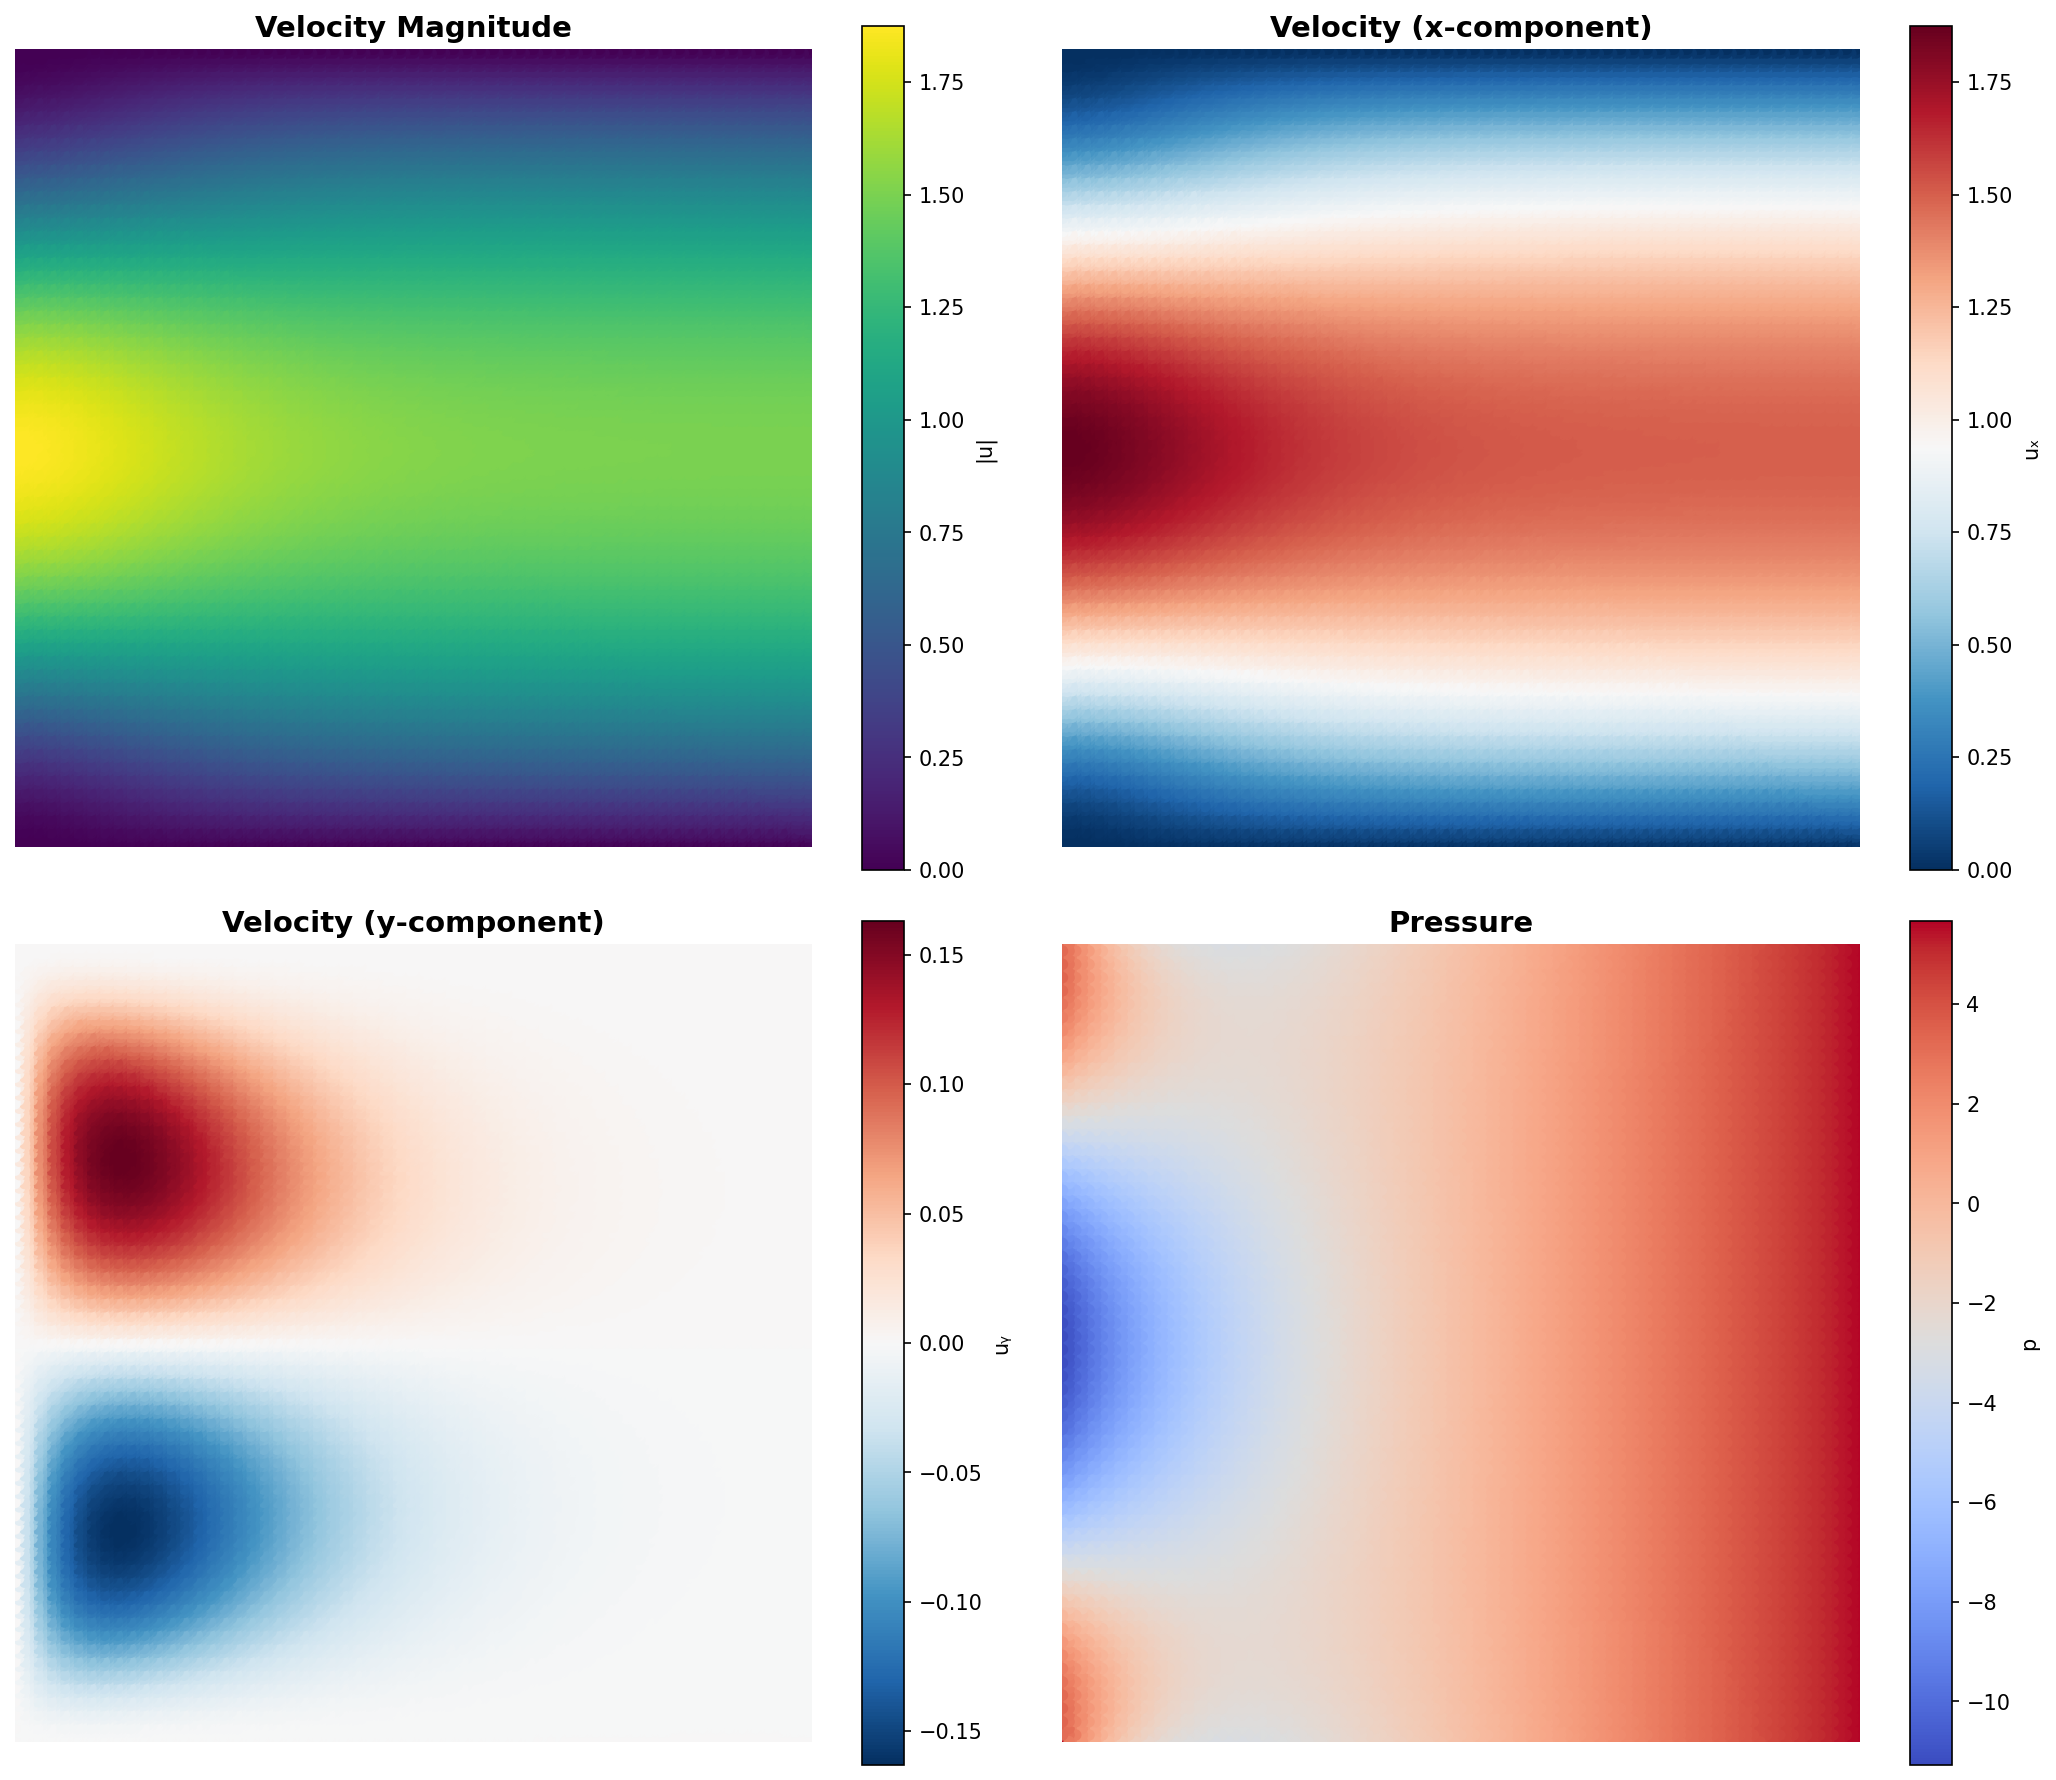

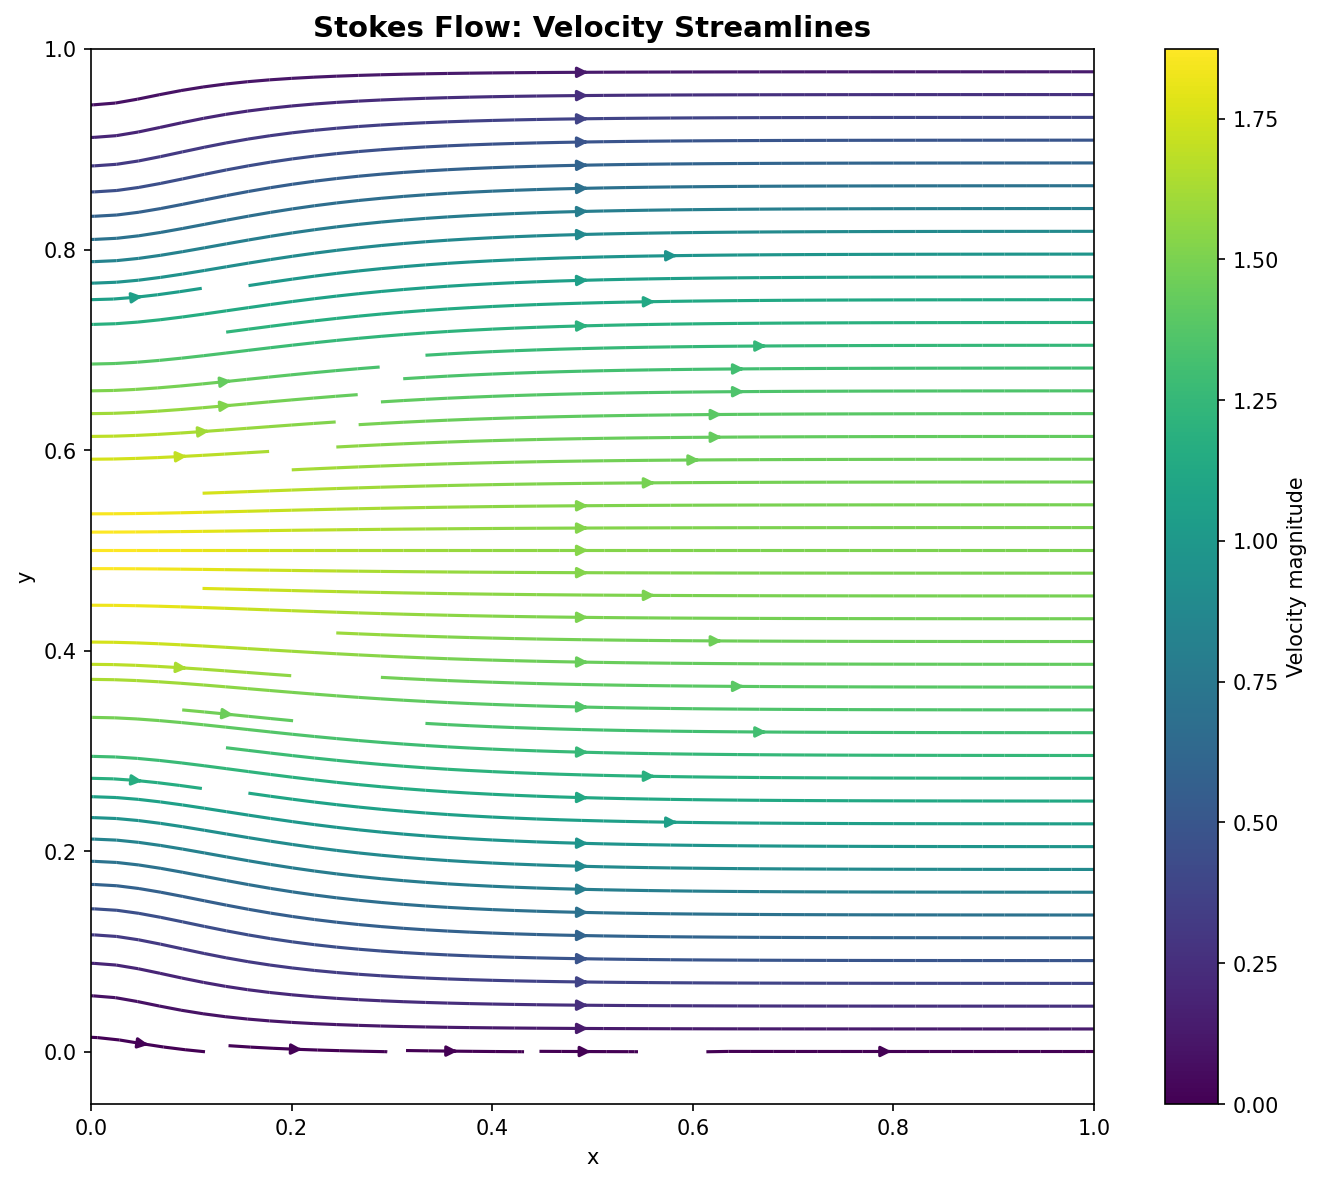

In [4]:
from IPython.display import Image, display, HTML


display(Image(f"stokes_solution_{INLET_CHOICE}.png"))
display(HTML("<br>"))
display(Image(f"stokes_streamlines_{INLET_CHOICE}.png", width=400))